<a href="https://colab.research.google.com/github/danielabustamante1-design/Cincias-de-datos-4/blob/main/Taller_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)


# Punto 1. Filtrado Condicional y Reemplazo

In [213]:
arr = np.random.randint(1, 1001, 100)

df = pd.DataFrame({'Valores': arr})

condicion = (df['Valores'] % 3 == 0) | (df['Valores'] % 5 == 0)

media = df.loc[~condicion, 'Valores'].mean()

df.loc[condicion, 'Valores'] = media

print(df.head())

    Valores
0  103.0000
1  436.0000
2  480.5625
3  271.0000
4  107.0000


/tmp/ipykernel_3520/661936495.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '480.5625' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[condicion, 'Valores'] = media


# Punto 2. Manejo de Outliers Estadísticos

In [214]:
df_salarios = pd.DataFrame({
    'Salario': np.concatenate([
        np.random.normal(3000,500,100),
        [10000,12000,500]
    ])
})

Q1 = df_salarios['Salario'].quantile(0.25)
Q3 = df_salarios['Salario'].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

p5 = df_salarios['Salario'].quantile(0.05)
p95 = df_salarios['Salario'].quantile(0.95)

df_salarios.loc[df_salarios['Salario'] > lim_sup, 'Salario'] = p95
df_salarios.loc[df_salarios['Salario'] < lim_inf, 'Salario'] = p5

print(df_salarios.describe())

           Salario
count   103.000000
mean   3019.600631
std     553.150988
min    1910.832877
25%    2583.403568
50%    3012.750334
75%    3365.051401
max    4471.831708


Punto 3. Reestructuración de Datos (Melt)

In [215]:
df = pd.DataFrame({
    'Producto':['A','B','C'],
    'Enero':[100,200,300],
    'Febrero':[150,250,350],
    'Marzo':[180,280,380]
})

df_largo = pd.melt(
    df,
    id_vars='Producto',
    var_name='Mes',
    value_name='Ventas'
)

print(df_largo)

  Producto      Mes  Ventas
0        A    Enero     100
1        B    Enero     200
2        C    Enero     300
3        A  Febrero     150
4        B  Febrero     250
5        C  Febrero     350
6        A    Marzo     180
7        B    Marzo     280
8        C    Marzo     380


Punto 4. Agrupación y Transformación con Lambda

In [216]:
df_emp = pd.DataFrame({
    'Departamento':['Ventas','Ventas','TI','TI'],
    'Proyecto':['P1','P2','P1','P2'],
    'Horas':[40,60,30,70]
})

df_emp['Porcentaje_Depto'] = (
    df_emp.groupby('Departamento')['Horas']
    .transform(lambda x: x/x.sum()*100)
)

print(df_emp)

  Departamento Proyecto  Horas  Porcentaje_Depto
0       Ventas       P1     40              40.0
1       Ventas       P2     60              60.0
2           TI       P1     30              30.0
3           TI       P2     70              70.0


Punto 5. Reindexación y Datos Faltantes Temporales

In [217]:
fechas = pd.to_datetime([
    '2026-01-01','2026-01-03','2026-01-06',
    '2026-01-08','2026-01-12','2026-01-15'
])

serie = pd.Series(
    np.random.randint(10,100,len(fechas)),
    index=fechas
)

rango = pd.date_range('2026-01-01','2026-01-15')

serie = serie.reindex(rango)

serie = serie.interpolate(method='linear')

print(serie)

2026-01-01    89.000000
2026-01-02    50.500000
2026-01-03    12.000000
2026-01-04    17.666667
2026-01-05    23.333333
2026-01-06    29.000000
2026-01-07    48.500000
2026-01-08    68.000000
2026-01-09    62.250000
2026-01-10    56.500000
2026-01-11    50.750000
2026-01-12    45.000000
2026-01-13    39.333333
2026-01-14    33.666667
2026-01-15    28.000000
Freq: D, dtype: float64


Punto 6. Análisis de Tablas Cruzadas (Crosstab)

In [218]:
df = pd.DataFrame({
    'Categoria_Producto':np.random.choice(['Tecnologia','Ropa','Hogar'],100),
    'Metodo_Pago':np.random.choice(['Tarjeta','Efectivo','Transferencia'],100),
    'Satisfecho':np.random.choice(['Si','No'],100)
})

tabla = pd.crosstab(
    [df['Categoria_Producto'],df['Metodo_Pago']],
    df['Satisfecho'],
    normalize='index'
)*100

print(tabla)

Satisfecho                               No         Si
Categoria_Producto Metodo_Pago                        
Hogar              Efectivo       50.000000  50.000000
                   Tarjeta        33.333333  66.666667
                   Transferencia  37.500000  62.500000
Ropa               Efectivo       66.666667  33.333333
                   Tarjeta        42.857143  57.142857
                   Transferencia  66.666667  33.333333
Tecnologia         Efectivo       46.153846  53.846154
                   Tarjeta        63.636364  36.363636
                   Transferencia  64.285714  35.714286


Punto 7. Combinación Compleja de DataFrames (Merge)

In [219]:
df_usuarios = pd.DataFrame({
    'ID':[1,2,3,4,5],
    'Nombre':['Ana','Juan','Pedro','Luis','Maria'],
    'Pais':['Colombia','México','Perú','México','Colombia']
})

df_transacciones = pd.DataFrame({
    'ID_Transaccion':[1,2,3,4,5],
    'ID_Usuario':[1,2,3,4,5],
    'Monto':[500,1200,300,1500,900]
})

promedio = df_transacciones['Monto'].mean()

resultado = (
    df_usuarios.merge(
        df_transacciones,
        left_on='ID',
        right_on='ID_Usuario'
    )
)

resultado = resultado[
    (resultado['Pais'].isin(['Colombia','México'])) &
    (resultado['Monto'] > promedio)
]

print(resultado)

   ID Nombre      Pais  ID_Transaccion  ID_Usuario  Monto
1   2   Juan    México               2           2   1200
3   4   Luis    México               4           4   1500
4   5  Maria  Colombia               5           5    900


8. Binning de Variables Continuas

In [220]:
df = pd.DataFrame({
    'Edad':np.random.randint(10,80,100),
    'Ingresos':np.random.randint(1000,10000,100)
})

bins = [0,18,35,60,120]

labels = [
    'Junior',
    'Young Adult',
    'Adult',
    'Senior'
]

df['Categoria'] = pd.cut(
    df['Edad'],
    bins=bins,
    labels=labels
)

print(df['Categoria'].value_counts())

print(df.groupby('Categoria')['Ingresos'].mean())

Categoria
Adult          35
Young Adult    30
Senior         24
Junior         11
Name: count, dtype: int64
Categoria
Junior         4100.090909
Young Adult    5696.433333
Adult          5817.942857
Senior         5819.291667
Name: Ingresos, dtype: float64


/tmp/ipykernel_3520/3424502434.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Categoria')['Ingresos'].mean())


9. Operaciones de Ventana Móvil (Rolling)

In [221]:
fechas = pd.date_range('2026-01-01', periods=60)

df = pd.DataFrame({
    'Fecha':fechas,
    'Precio':np.random.normal(100,5,60)
})

df['Media_Movil_5'] = (
    df['Precio']
    .rolling(5)
    .mean()
)

df['Desv_Movil_5'] = (
    df['Precio']
    .rolling(5)
    .std()
)

print(df.head())

       Fecha      Precio  Media_Movil_5  Desv_Movil_5
0 2026-01-01  103.558074            NaN           NaN
1 2026-01-02   94.376790            NaN           NaN
2 2026-01-03   92.329429            NaN           NaN
3 2026-01-04  106.388384            NaN           NaN
4 2026-01-05  101.661570      99.662849      6.044046


10. Parseo de Fechas Extracciones Complejas

In [222]:
df = pd.DataFrame({
    'Fecha':[
        '2026-04-15 14:30:00',
        '15/04/2026',
        '2026-05-01'
    ]
})

df['Fecha'] = pd.to_datetime(
    df['Fecha'],
    format='mixed',
    dayfirst=True
)

dias = {
0:'Lunes',
1:'Martes',
2:'Miércoles',
3:'Jueves',
4:'Viernes',
5:'Sábado',
6:'Domingo'
}

df['Dia_Semana'] = (
    df['Fecha']
    .dt.dayofweek
    .map(dias)
)

df['Semana_Año'] = (
    df['Fecha']
    .dt.isocalendar()
    .week
)

df['Fin_Semana'] = (
    df['Fecha']
    .dt.dayofweek >= 5
)

print(df)

                Fecha Dia_Semana  Semana_Año  Fin_Semana
0 2026-04-15 14:30:00  Miércoles          16       False
1 2026-04-15 00:00:00  Miércoles          16       False
2 2026-05-01 00:00:00    Viernes          18       False


11. Gráfico de Dispersión con Doble Codificación

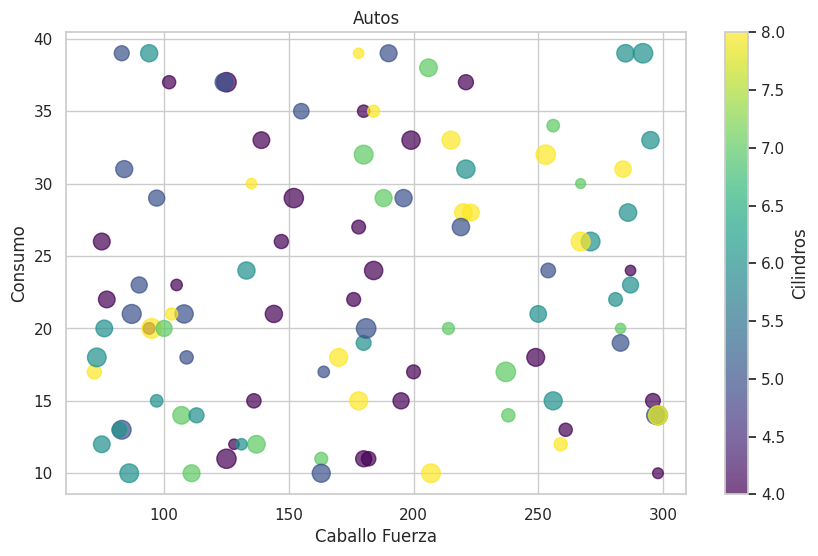

In [223]:
autos = pd.DataFrame({
    'Caballo_Fuerza':np.random.randint(70,300,100),
    'Consumo_Gasolina':np.random.randint(10,40,100),
    'Peso':np.random.randint(1000,4000,100),
    'Cilindros':np.random.randint(4,9,100)
})

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    autos['Caballo_Fuerza'],
    autos['Consumo_Gasolina'],
    s=autos['Peso']/20,
    c=autos['Cilindros'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(scatter,label='Cilindros')
plt.xlabel('Caballo Fuerza')
plt.ylabel('Consumo')
plt.title('Autos')
plt.show()

12. Comparativa de Distribuciones (FacetGrid)

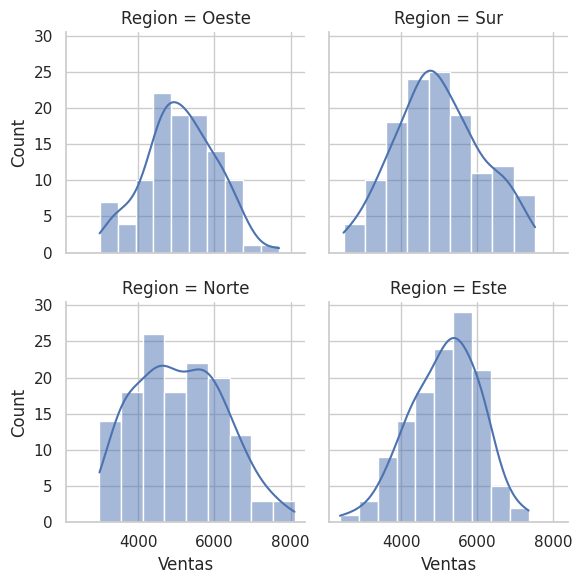

In [224]:
df = pd.DataFrame({
    'Region':np.random.choice(
        ['Norte','Sur','Este','Oeste'],
        500
    ),
    'Ventas':np.random.normal(
        5000,
        1000,
        500
    )
})

g = sns.FacetGrid(
    df,
    col='Region',
    col_wrap=2
)

g.map_dataframe(
    sns.histplot,
    x='Ventas',
    kde=True
)

plt.show()

13. Gráfico de Líneas Multieje (Twinx)

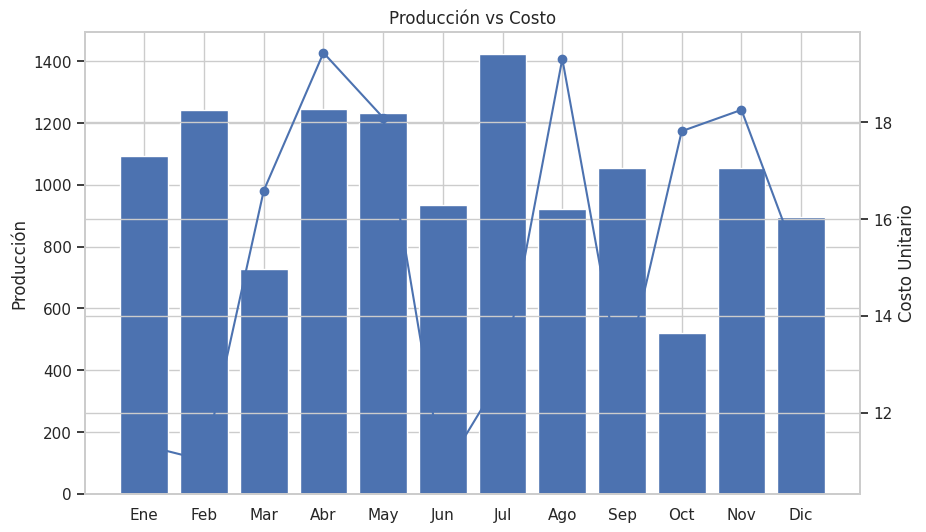

In [225]:
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

produccion = np.random.randint(500,1500,12)
costo = np.random.uniform(10,20,12)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(meses,produccion)
ax1.set_ylabel('Producción')

ax2 = ax1.twinx()
ax2.plot(meses,costo,marker='o')
ax2.set_ylabel('Costo Unitario')

plt.title('Producción vs Costo')
plt.show()

14. Mapa de Calor de Correlación Personalizado

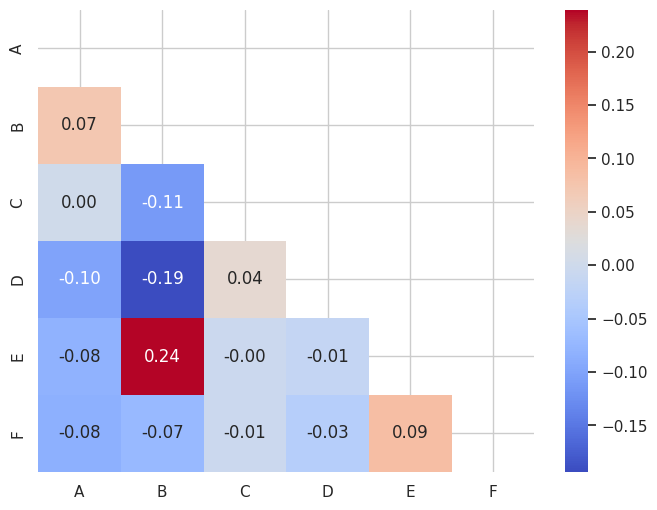

In [226]:
df = pd.DataFrame(
    np.random.randn(100,6),
    columns=list('ABCDEF')
)

corr = df.corr()

mask = np.triu(np.ones_like(corr,dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.show()

15. Subplots Combinados (Matplotlib + Seaborn)

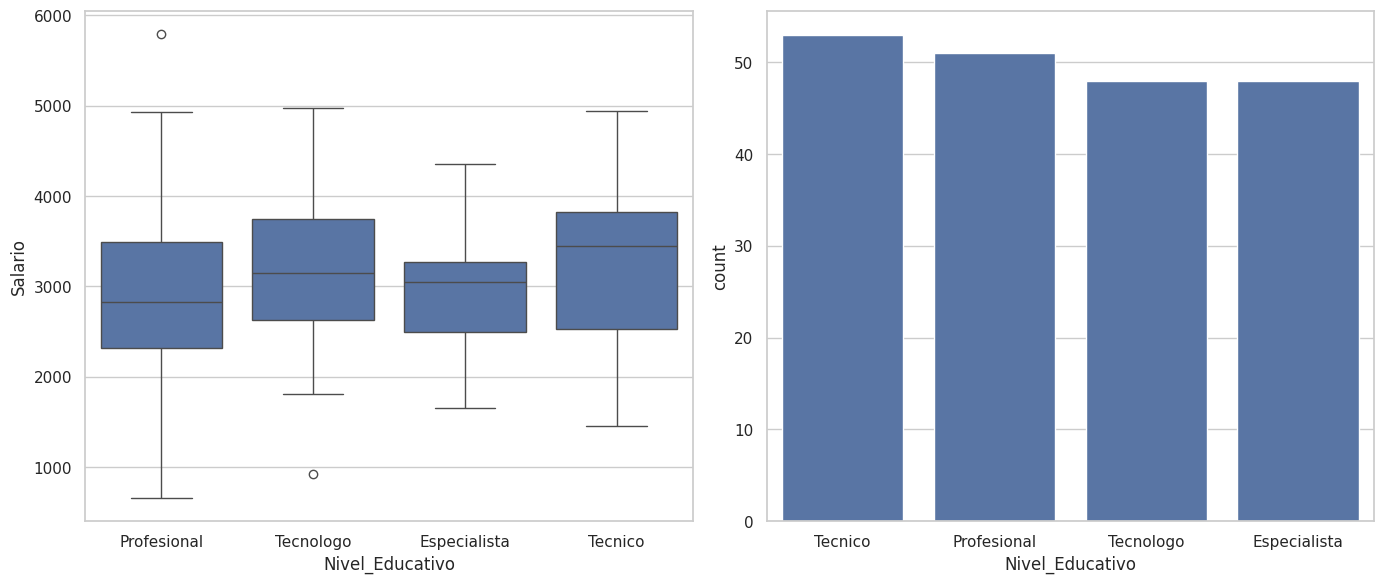

In [227]:
df = pd.DataFrame({
    'Nivel_Educativo':np.random.choice(
        ['Tecnico','Tecnologo','Profesional','Especialista'],
        200
    ),
    'Salario':np.random.normal(
        3000,
        800,
        200
    )
})

fig, ax = plt.subplots(
    1,2,
    figsize=(14,6)
)

sns.boxplot(
    data=df,
    x='Nivel_Educativo',
    y='Salario',
    ax=ax[0]
)

orden = (
    df['Nivel_Educativo']
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    x='Nivel_Educativo',
    order=orden,
    ax=ax[1]
)

plt.tight_layout()
plt.show()

16. Análisis de Series Temporales y Tendencias

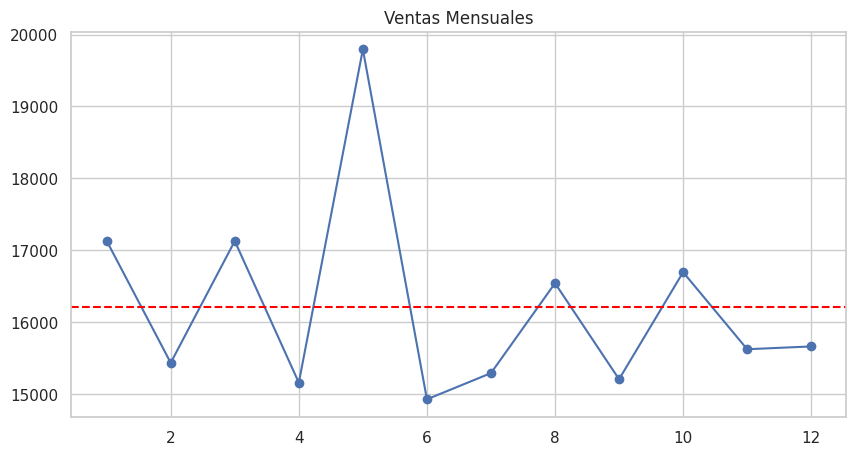

In [228]:
fechas = pd.date_range(
    '2025-01-01',
    periods=365
)

ventas = np.random.randint(
    100,
    1000,
    365
)

df = pd.DataFrame({
    'Fecha':fechas,
    'Ventas':ventas
})

mensual = (
    df.groupby(
        df['Fecha'].dt.month
    )['Ventas']
    .sum()
)

promedio = mensual.mean()

plt.figure(figsize=(10,5))

plt.plot(
    mensual.index,
    mensual.values,
    marker='o'
)

plt.axhline(
    promedio,
    color='red',
    linestyle='--'
)

plt.title('Ventas Mensuales')
plt.show()

17. Análisis de Comportamiento de Clientes

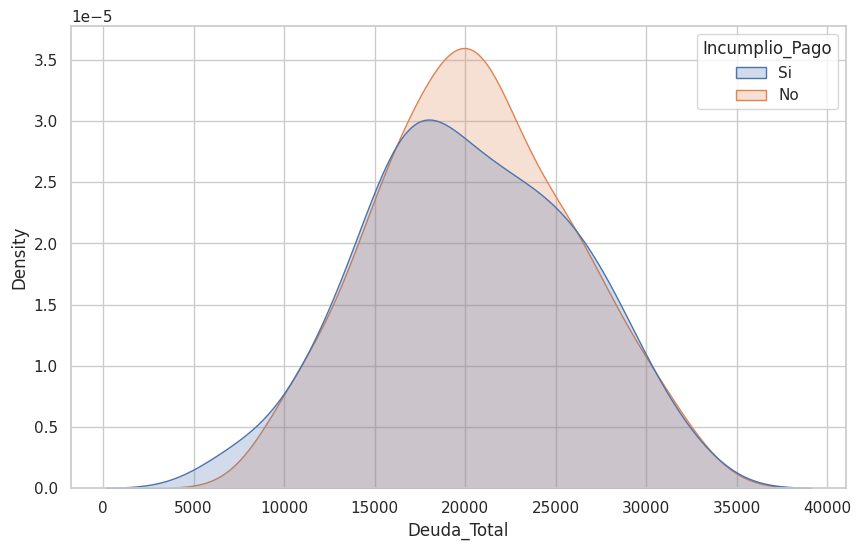

In [229]:
df = pd.DataFrame({
    'Puntaje_Credito':np.random.randint(
        300,
        850,
        500
    ),
    'Deuda_Total':np.random.normal(
        20000,
        5000,
        500
    ),
    'Incumplio_Pago':np.random.choice(
        ['Si','No'],
        500
    )
})

df2 = df[
    df['Puntaje_Credito'] > 600
]

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df2,
    x='Deuda_Total',
    hue='Incumplio_Pago',
    fill=True
)

plt.show()

18. Rendimiento Académico y Asistencia

                                   Porcentaje_Asistencia  Nota_Final
Materia                                                             
Fisica      Porcentaje_Asistencia               1.000000    0.039287
            Nota_Final                          0.039287    1.000000
Matematicas Porcentaje_Asistencia               1.000000    0.153749
            Nota_Final                          0.153749    1.000000
Quimica     Porcentaje_Asistencia               1.000000   -0.011190
            Nota_Final                         -0.011190    1.000000


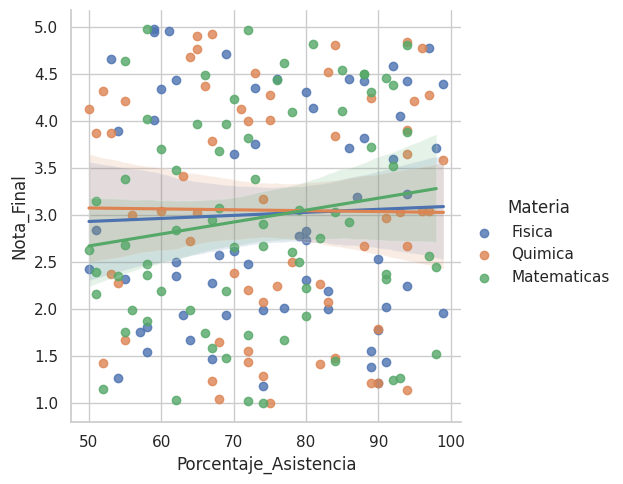

In [230]:
df = pd.DataFrame({
    'Estudiante':range(200),
    'Porcentaje_Asistencia':
        np.random.randint(50,100,200),
    'Nota_Final':
        np.random.uniform(1,5,200),
    'Materia':
        np.random.choice(
            ['Matematicas','Fisica','Quimica'],
            200
        )
})

correlaciones = (
    df.groupby('Materia')
    [['Porcentaje_Asistencia',
      'Nota_Final']]
    .corr()
)

print(correlaciones)

sns.lmplot(
    data=df,
    x='Porcentaje_Asistencia',
    y='Nota_Final',
    hue='Materia'
)

plt.show()

19. Composición de Categorías Menores ("Otros")

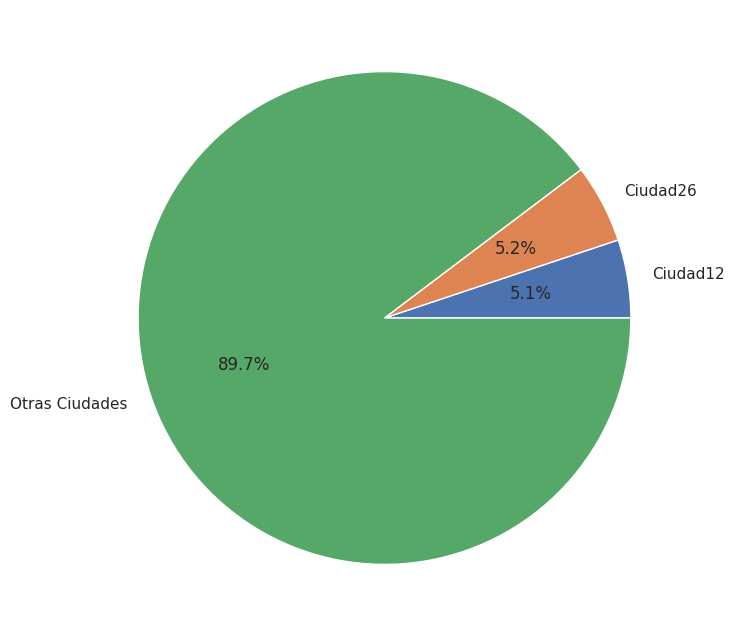

In [231]:
ciudades = [
    f'Ciudad{i}'
    for i in range(1,35)
]

df = pd.DataFrame({
    'Ciudad_Origen':
        np.random.choice(
            ciudades,
            500
        ),
    'Pasajeros':
        np.random.randint(
            1,
            100,
            500
        )
})

aporte = (
    df.groupby('Ciudad_Origen')
    ['Pasajeros']
    .sum()
)

aporte = (
    aporte /
    aporte.sum()
)*100

ciudades_peq = aporte[
    aporte < 5
].index

df['Ciudad_Agrupada'] = (
    df['Ciudad_Origen']
    .replace(
        ciudades_peq,
        'Otras Ciudades'
    )
)

pie = (
    df.groupby(
        'Ciudad_Agrupada'
    )['Pasajeros']
    .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    pie,
    labels=pie.index,
    autopct='%1.1f%%'
)

plt.show()

20. Diagrama de Violín con División (Split Violin Plot)

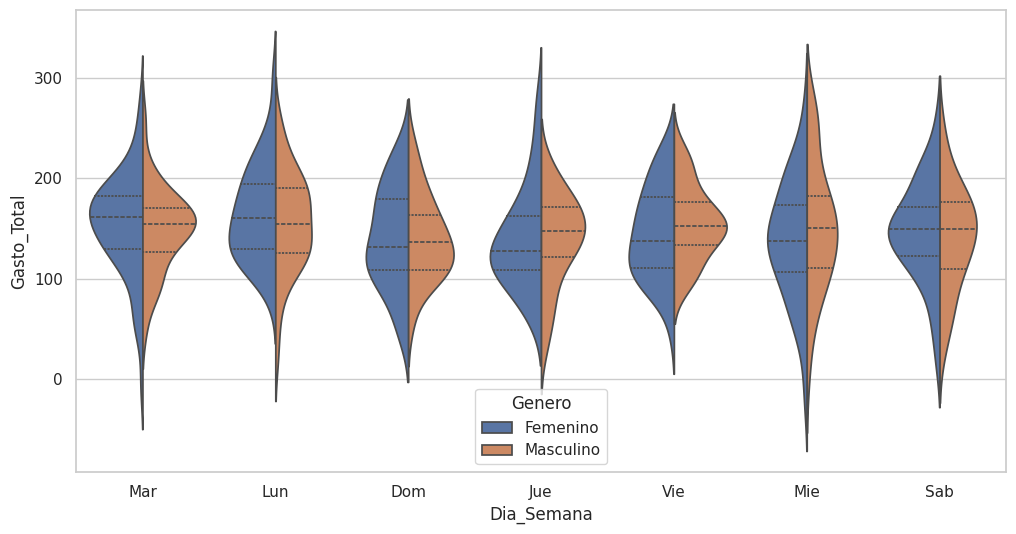

In [232]:
df = pd.DataFrame({
    'Dia_Semana':
        np.random.choice(
            ['Lun','Mar','Mie','Jue','Vie','Sab','Dom'],
            500
        ),
    'Gasto_Total':
        np.random.normal(
            150,
            50,
            500
        ),
    'Genero':
        np.random.choice(
            ['Masculino','Femenino'],
            500
        )
})

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='Dia_Semana',
    y='Gasto_Total',
    hue='Genero',
    split=True,
    inner='quartile'
)

plt.show()